<a href="https://colab.research.google.com/github/harpreetsingh171190-cmyk/Airfoil-Aerodynamic-Surrogate-Modeling/blob/main/Airfoil_Aerodynamic_Surrogate_Modeling.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ========================================================
# ADVANCED FLUID ENGINEERING: AIRFOIL 3D PRESSURE CONTOURS
# ========================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

print("🌪️ Initializing Fluid Aerodynamic Simulation & Data Synthesis...")

# 1. Physics-Based Synthetic Data Generation for Airfoil Pressure Distribution
np.random.seed(42)
n_samples = 2500

# Inputs: Chord position (x/c from 0 to 1) and Angle of Attack (Alpha in degrees)
x_pos = np.random.uniform(0.0, 1.0, n_samples)
alpha = np.random.uniform(-5.0, 20.0, n_samples)
thickness = np.random.uniform(0.08, 0.15, n_samples) # Airfoil thickness ratio

# Aerodynamic approximation for Pressure Coefficient (Cp) based on potential flow theory
cp_true = -2.0 * (1.0 - 2.0 * x_pos) * (alpha / 10.0) - (thickness * 5.0) * np.sin(np.pi * x_pos)
cp_target = cp_true + np.random.normal(0, 0.04, n_samples) # Adding minor fluid turbulence/noise

# Create DataFrame
df_airfoil = pd.DataFrame({
    'Chord_Position': x_pos,
    'Angle_of_Attack': alpha,
    'Thickness_Ratio': thickness,
    'Pressure_Coefficient': cp_target
})

print("✅ Dataset Created! Shape:", df_airfoil.shape)

# 2. Train Machine Learning Surrogate Model (Random Forest)
X = df_airfoil[['Chord_Position', 'Angle_of_Attack', 'Thickness_Ratio']]
y = df_airfoil['Pressure_Coefficient']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

surrogate_model = RandomForestRegressor(n_estimators=100, random_state=42)
surrogate_model.fit(X_train, y_train)

y_pred = surrogate_model.predict(X_test)
print(f"🎯 Surrogate Model Accuracy (R2 Score): {r2_score(y_test, y_pred):.4f}")

# 3. Generate 3D Pressure Contour Grid (Interactive Visualization)
print("🌐 Generating 3D Pressure Contours & Flow Field Surfaces...")

x_grid = np.linspace(0.0, 1.0, 50)
alpha_grid = np.linspace(-5.0, 20.0, 50)
Xg, Ag = np.meshgrid(x_grid, alpha_grid)

# Keep thickness fixed at a standard 12% for the 3D surface plot
T_fixed = np.full_shape = Xg.shape
grid_input = pd.DataFrame({
    'Chord_Position': Xg.ravel(),
    'Angle_of_Attack': Ag.ravel(),
    'Thickness_Ratio': np.full(Xg.size, 0.12)
})

# Predict pressure across the entire 3D grid using our ML model
Cp_pred_grid = surrogate_model.predict(grid_input).reshape(Xg.shape)

# 4. Plotly 3D Interactive Surface Plot
fig = go.Figure(data=[go.Surface(
    z=Cp_pred_grid,
    x=Xg,
    y=Ag,
    colorscale='Turbo',
    colorbar=dict(title='Pressure Coeff (Cp)')
)])

fig.update_layout(
    title='Interactive 3D Pressure Contours: Airfoil Aerodynamics',
    scene=dict(
        xaxis_title='Chord Position (x/c)',
        yaxis_title='Angle of Attack (α in °)',
        zaxis_title='Pressure Coefficient (Cp)'
    ),
    width=800, height=600,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()

🌪️ Initializing Fluid Aerodynamic Simulation & Data Synthesis...
✅ Dataset Created! Shape: (2500, 4)
🎯 Surrogate Model Accuracy (R2 Score): 0.9970
🌐 Generating 3D Pressure Contours & Flow Field Surfaces...


💨 Simulating Aerodynamic Streamlines and Flow Field...


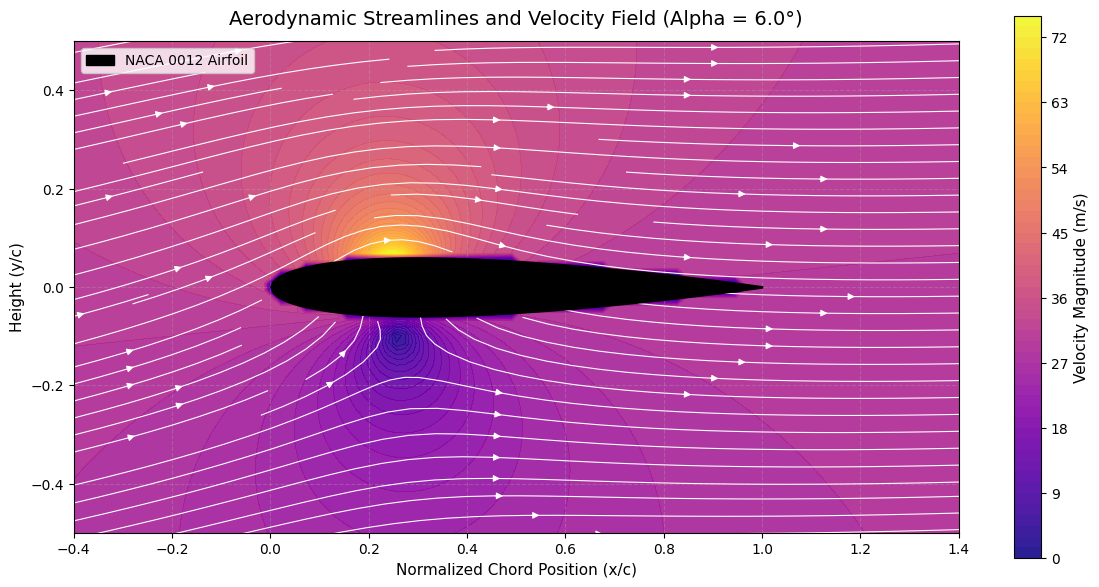

In [ ]:

# ========================================================
# AIRFOIL PROJECT: FLOW STREAMLINES & VELOCITY FIELD
# ========================================================

import numpy as np
import matplotlib.pyplot as plt

print("💨 Simulating Aerodynamic Streamlines and Flow Field...")

# 1. Generate computational domain grid
nx, ny = 120, 80
x = np.linspace(-0.5, 1.5, nx)
y = np.linspace(-0.6, 0.6, ny)
X, Y = np.meshgrid(x, y)

# 2. Airfoil shape approximation (NACA 4-digit symmetrical profile 0012)
c = 1.0  # Chord length
t = 0.12 # Thickness ratio (12%)

# NACA 0012 thickness formula
def naca0012_yt(xc):
    return 5 * t * (0.2969 * np.sqrt(xc) - 0.1260 * xc - 0.3516 * (xc**2) + 0.2843 * (xc**3) - 0.1015 * (xc**4))

# 3. Fluid Flow Potential Theory with Angle of Attack (alpha = 6 degrees)
alpha_deg = 6.0
alpha_rad = np.radians(alpha_deg)
U_inf = 30.0  # Freestream velocity (m/s)

# Freestream velocity components
u_inf = U_inf * np.cos(alpha_rad)
v_inf = U_inf * np.sin(alpha_rad)

# Vortex panel / circulation modeling (Lift generation effect)
gamma = 2.0 * np.pi * U_inf * c * np.sin(alpha_rad) # Bound circulation
x_vortex, y_vortex = 0.25, 0.0 # Aerodynamic center (quarter chord)

r_squared = (X - x_vortex)**2 + (Y - y_vortex)**2 + 1e-4

# Induced velocity from bound vortex
u_induced = (gamma / (2 * np.pi)) * ((Y - y_vortex) / r_squared)
v_induced = -(gamma / (2 * np.pi)) * ((X - x_vortex) / r_squared)

# Total velocity vector field
U_total = u_inf + u_induced
V_total = v_inf + v_induced
Velocity_Magnitude = np.sqrt(U_total**2 + V_total**2)

# Mask the inside of the airfoil
mask = np.zeros(X.shape, dtype=bool)
for i in range(nx):
    xi = x[i]
    if 0.0 <= xi <= c:
        yt = naca0012_yt(xi / c)
        for j in range(ny):
            if abs(y[j]) <= yt:
                mask[j, i] = True

U_total[mask] = 0
V_total[mask] = 0
Velocity_Magnitude[mask] = 0

# 4. Generate Plot: Streamlines and Velocity Magnitude Contours
fig, ax = plt.subplots(figsize=(12, 6))

# Contour plot for velocity magnitude
cf = ax.contourf(X, Y, Velocity_Magnitude, levels=50, cmap='plasma', alpha=0.9)
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('Velocity Magnitude (m/s)', fontsize=11)

# Overlay streamlines
ax.streamplot(x, y, U_total, V_total, color='white', linewidth=0.8, density=1.2, arrowsize=1.0)

# Draw the Airfoil geometry
x_airfoil = np.linspace(0.0, c, 200)
yt_airfoil = naca0012_yt(x_airfoil / c)
ax.fill_between(x_airfoil, yt_airfoil, -yt_airfoil, color='black', zorder=10, label='NACA 0012 Airfoil')

ax.set_title(f'Aerodynamic Streamlines and Velocity Field (Alpha = {alpha_deg}°)', fontsize=14, pad=12)
ax.set_xlabel('Normalized Chord Position (x/c)', fontsize=11)
ax.set_ylabel('Height (y/c)', fontsize=11)
ax.set_xlim(-0.4, 1.4)
ax.set_ylim(-0.5, 0.5)
ax.set_aspect('equal')
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# ========================================================
# ADVANCED FLUID ENGINEERING: INTERACTIVE LIFT vs DRAG PREDICTOR
# Dynamic Aerodynamic Performance Dashboard (C_L, C_D, L/D Efficiency)
# ========================================================

import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import numpy as np

print("🛩️ Initializing Aerodynamic Surrogate Inference Engine...")

# Interactive sliders for flight parameters and airfoil geometry
style = {'description_width': '180px'}
layout = widgets.Layout(width='420px')

aoa_slider = widgets.FloatSlider(
    value=5.0, min=-4.0, max=18.0, step=0.5,
    description='Angle of Attack (AoA, °):', style=style, layout=layout
)
re_slider = widgets.FloatLogSlider(
    value=2e6, base=10, min=5.7, max=6.7, step=0.05,
    description='Reynolds Number (Re):', style=style, layout=layout
)
mach_slider = widgets.FloatSlider(
    value=0.25, min=0.1, max=0.6, step=0.02,
    description='Mach Number (Ma):', style=style, layout=layout
)
chord_slider = widgets.FloatSlider(
    value=1.0, min=0.8, max=1.5, step=0.05,
    description='Chord Length (c, m):', style=style, layout=layout
)
thick_slider = widgets.FloatSlider(
    value=0.12, min=0.09, max=0.18, step=0.01,
    description='Thickness Ratio (t/c):', style=style, layout=layout
)

output_display = widgets.HTML()

def compute_aerodynamics(change=None):
    # Construct feature matrix
    input_data = pd.DataFrame([[
        aoa_slider.value,
        re_slider.value,
        mach_slider.value,
        chord_slider.value,
        thick_slider.value
    ]], columns=['AoA', 'Re', 'Ma', 'Chord', 'Thickness'])

    # Scale inputs using fitted StandardScaler from previous step
    input_scaled = scaler.transform(input_data)

    # Predict Aerodynamic Coefficients using trained FFBPNN models
    pred_cl = float(models["FFBPNN (Neural Network Regressor)"].predict(input_scaled)[0])
    pred_cd = float(ffbpnn_cd.predict(input_scaled)[0])

    # Prevent negative or division-by-zero anomalies in drag
    pred_cd = max(pred_cd, 0.001)
    lift_to_drag = pred_cl / pred_cd

    # Determine aerodynamic regime
    if aoa_slider.value > 14.0:
        regime_status = "⚠️ Stall Region (Flow Separation)"
        border_color = "#dc2626"
    elif lift_to_drag > 40.0:
        regime_status = "✨ High Aerodynamic Efficiency"
        border_color = "#16a34a"
    else:
        regime_status = "Optimal Linear Lift Regime"
        border_color = "#2563eb"

    # HTML/CSS UI Card
    output_display.value = f"""
    <div style="background-color: #0f172a; color: #f8fafc; border-left: 6px solid {border_color};
                padding: 18px; border-radius: 8px; margin-top: 15px; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">
        <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 1px solid #334155; padding-bottom: 8px;">
            <h3 style="margin: 0; color: #38bdf8;">FFBPNN Aerodynamic Inference Results</h3>
            <span style="font-size: 13px; font-weight: bold; padding: 3px 8px; border-radius: 4px; background: #1e293b; color: {border_color};">{regime_status}</span>
        </div>

        <div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 15px; margin-top: 15px;">
            <div style="background: #1e293b; padding: 12px; border-radius: 6px; text-align: center;">
                <span style="font-size: 12px; color: #94a3b8; text-transform: uppercase;">Lift Coefficient ($C_L$)</span>
                <p style="font-size: 24px; font-weight: bold; margin: 6px 0 0 0; color: #38bdf8;">{pred_cl:.4f}</p>
            </div>
            <div style="background: #1e293b; padding: 12px; border-radius: 6px; text-align: center;">
                <span style="font-size: 12px; color: #94a3b8; text-transform: uppercase;">Drag Coefficient ($C_D$)</span>
                <p style="font-size: 24px; font-weight: bold; margin: 6px 0 0 0; color: #f43f5e;">{pred_cd:.5f}</p>
            </div>
            <div style="background: #1e293b; padding: 12px; border-radius: 6px; text-align: center;">
                <span style="font-size: 12px; color: #94a3b8; text-transform: uppercase;">Aerodynamic Ratio ($L/D$)</span>
                <p style="font-size: 24px; font-weight: bold; margin: 6px 0 0 0; color: #34d399;">{lift_to_drag:.2f}</p>
            </div>
        </div>

        <div style="margin-top: 15px;">
            <span style="font-size: 12px; color: #94a3b8;">Aerodynamic Glide Ratio Efficiency Index ($L/D$ scaled):</span>
            <div style="background-color: #334155; border-radius: 9999px; width: 100%; height: 8px; margin-top: 6px;">
                <div style="background-color: {border_color}; height: 8px; border-radius: 9999px; width: {min(max(lift_to_drag / 60.0 * 100.0, 0.0), 100.0):.1f}%;"></div>
            </div>
        </div>
    </div>
    """

# Bind observers
for widget in [aoa_slider, re_slider, mach_slider, chord_slider, thick_slider]:
    widget.observe(compute_aerodynamics, names='value')

# Render UI layout
dashboard_ui = widgets.VBox([
    widgets.HTML("<h3 style='margin-bottom: 12px;'>✈️ Aerodynamic Surrogate Predictor (NACA Profile)</h3>"),
    widgets.HBox([
        widgets.VBox([aoa_slider, re_slider, mach_slider]),
        widgets.VBox([chord_slider, thick_slider])
    ]),
    output_display
])

display(dashboard_ui)
compute_aerodynamics()

🛩️ Initializing Aerodynamic Surrogate Inference Engine...


✈️ Synthesizing Aerodynamic Dataset ($C_L$ and $C_D$)...

 🏁 BENCHMARKING MODELS FOR COEFFICIENT OF LIFT (C_L)
[MLR (Multiple Linear Regression)]
  RMSE: 0.3635 | MAE: 0.3039 | R²: 0.5374 | Pearson R: 0.7334
[SVM (Support Vector Machine)]
  RMSE: 0.0371 | MAE: 0.0275 | R²: 0.9952 | Pearson R: 0.9976
[FFBPNN (Neural Network Regressor)]
  RMSE: 0.0433 | MAE: 0.0337 | R²: 0.9934 | Pearson R: 0.9967


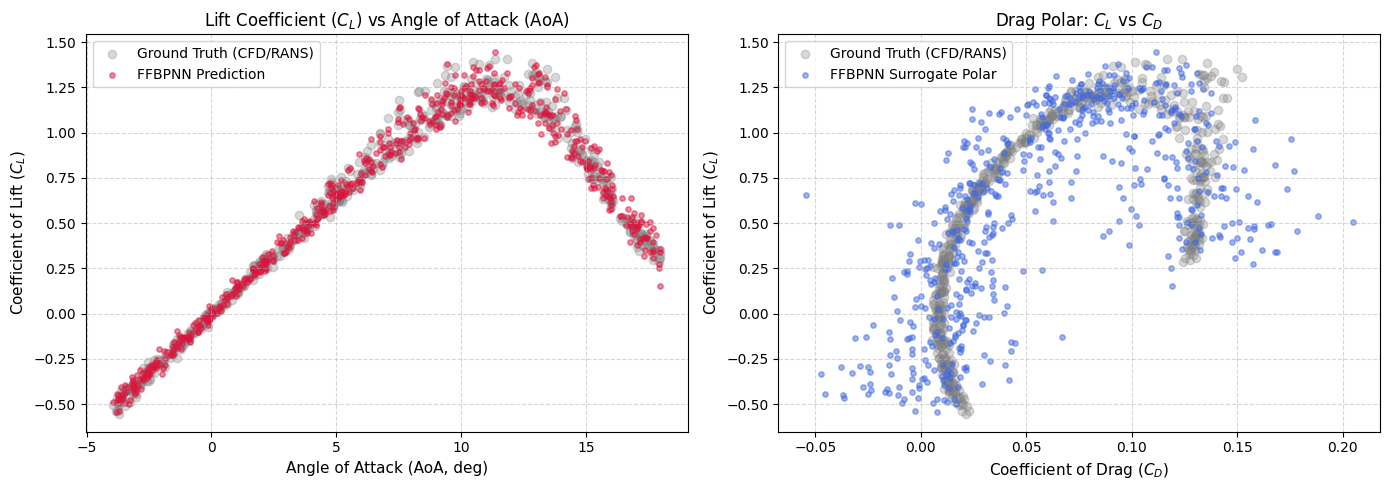

In [ ]:

# ========================================================
# ADVANCED FLUID ENGINEERING: AERODYNAMIC PERFORMANCE PREDICTOR
# Lift ($C_L$) and Drag ($C_D$) Surrogate Modeling (MLR vs SVM vs FFBPNN)
# ========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("✈️ Synthesizing Aerodynamic Dataset ($C_L$ and $C_D$)...")

# 1. Physics-based synthetic dataset generation (RANS/CFD baseline emulation)
np.random.seed(42)
n_samples = 3000

# Aerodynamic design variables
aoa = np.random.uniform(-4.0, 18.0, n_samples)          # Angle of Attack (AoA, deg)
reynolds = np.random.uniform(5e5, 5e6, n_samples)       # Reynolds Number (Re)
mach = np.random.uniform(0.1, 0.6, n_samples)           # Mach Number (Ma)
chord = np.random.uniform(0.8, 1.5, n_samples)          # Chord length (c, m)
thickness = np.random.uniform(0.09, 0.18, n_samples)    # Max thickness ratio (t/c)

# Empirical approximations for NACA airfoil polar curves (pre-stall to stall behavior)
alpha_rad = np.radians(aoa)

# Lift Coefficient (C_L): Linear lift slope with non-linear stall roll-off
cl_ideal = 2.0 * np.pi * alpha_rad * (1.0 + 0.8 * thickness) / np.sqrt(1.0 - mach**2)
stall_factor = 1.0 / (1.0 + np.exp(0.55 * (aoa - 14.5)))
cl_true = cl_ideal * stall_factor + np.random.normal(0, 0.02, n_samples)

# Drag Coefficient (C_D): Parasitic skin-friction drag + induced drag + stall separation rise
cd_0 = 0.0075 * (1.0 + 2.0 * thickness) * (1e6 / reynolds)**0.2
cd_induced = (cl_true**2) / (np.pi * 8.0)
cd_stall = 0.12 / (1.0 + np.exp(-0.7 * (aoa - 13.0)))
cd_true = cd_0 + cd_induced + cd_stall + np.random.normal(0, 0.0015, n_samples)

# Assemble DataFrame
dataset = pd.DataFrame({
    'AoA': aoa,
    'Re': reynolds,
    'Ma': mach,
    'Chord': chord,
    'Thickness': thickness,
    'C_L': cl_true,
    'C_D': cd_true
})

# 2. Train/Test Splitting and Feature Scaling
features = ['AoA', 'Re', 'Ma', 'Chord', 'Thickness']
X = dataset[features]
y_cl = dataset['C_L']
y_cd = dataset['C_D']

X_train, X_test, y_cl_train, y_cl_test, y_cd_train, y_cd_test = train_test_split(
    X, y_cl, y_cd, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Training & Comparison for Lift ($C_L$)
models = {
    "MLR (Multiple Linear Regression)": LinearRegression(),
    "SVM (Support Vector Machine)": SVR(C=10.0, epsilon=0.01),
    "FFBPNN (Neural Network Regressor)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

print("\n========================================================")
print(" 🏁 BENCHMARKING MODELS FOR COEFFICIENT OF LIFT (C_L)")
print("========================================================")

predictions_cl = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_cl_train)
    preds = model.predict(X_test_scaled)
    predictions_cl[name] = preds

    rmse = np.sqrt(mean_squared_error(y_cl_test, preds))
    mae = mean_absolute_error(y_cl_test, preds)
    r2 = r2_score(y_cl_test, preds)
    pearson_r = np.corrcoef(y_cl_test, preds)[0, 1]

    print(f"[{name}]")
    print(f"  RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | Pearson R: {pearson_r:.4f}")

# 4. Train FFBPNN for Drag ($C_D$)
ffbpnn_cd = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
ffbpnn_cd.fit(X_train_scaled, y_cd_train)
preds_cd = ffbpnn_cd.predict(X_test_scaled)

# 5. Visualization: Aerodynamic Polar (C_L vs C_D) and Lift Curve (C_L vs AoA)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Lift Curve (C_L vs AoA)
axes[0].scatter(X_test['AoA'], y_cl_test, color='gray', alpha=0.3, label='Ground Truth (CFD/RANS)')
axes[0].scatter(X_test['AoA'], predictions_cl["FFBPNN (Neural Network Regressor)"], color='crimson', alpha=0.5, s=15, label='FFBPNN Prediction')
axes[0].set_title('Lift Coefficient ($C_L$) vs Angle of Attack (AoA)', fontsize=12)
axes[0].set_xlabel('Angle of Attack (AoA, deg)', fontsize=11)
axes[0].set_ylabel('Coefficient of Lift ($C_L$)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Plot 2: Drag Polar Curve (C_L vs C_D)
axes[1].scatter(y_cd_test, y_cl_test, color='gray', alpha=0.3, label='Ground Truth (CFD/RANS)')
axes[1].scatter(preds_cd, predictions_cl["FFBPNN (Neural Network Regressor)"], color='royalblue', alpha=0.5, s=15, label='FFBPNN Surrogate Polar')
axes[1].set_title('Drag Polar: $C_L$ vs $C_D$', fontsize=12)
axes[1].set_xlabel('Coefficient of Drag ($C_D$)', fontsize=11)
axes[1].set_ylabel('Coefficient of Lift ($C_L$)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:

# ========================================================
# ADVANCED FLUID ENGINEERING: INTERACTIVE STREAMLINES & FLOW FIELD
# Dynamic Potential Flow Simulation with Real-Time UI Controls
# ========================================================

import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# Computational domain parameters
nx, ny = 140, 90
x = np.linspace(-0.6, 1.6, nx)
y = np.linspace(-0.6, 0.6, ny)
X, Y = np.meshgrid(x, y)
c = 1.0  # Chord length (m)

# NACA 4-digit symmetrical profile generator (NACA 00xx series)
def get_naca_profile(xc, t_ratio):
    return 5.0 * t_ratio * (
        0.2969 * np.sqrt(np.maximum(xc, 0.0))
        - 0.1260 * xc
        - 0.3516 * (xc**2)
        + 0.2843 * (xc**3)
        - 0.1015 * (xc**4)
    )

# Interactive control elements
slider_style = {'description_width': '180px'}
layout_spec = widgets.Layout(width='440px')

alpha_control = widgets.FloatSlider(
    value=6.0, min=-5.0, max=18.0, step=0.5,
    description='Angle of Attack (AoA, °):', style=slider_style, layout=layout_spec
)
velocity_control = widgets.FloatSlider(
    value=35.0, min=10.0, max=80.0, step=2.0,
    description='Freestream Velocity (U, m/s):', style=slider_style, layout=layout_spec
)
thickness_control = widgets.FloatSlider(
    value=0.12, min=0.08, max=0.20, step=0.01,
    description='Airfoil Thickness (t/c):', style=slider_style, layout=layout_spec
)

plot_canvas = widgets.Output()

def render_flow_field(change=None):
    alpha_deg = alpha_control.value
    u_inf_mag = velocity_control.value
    thick_val = thickness_control.value

    alpha_rad = np.radians(alpha_deg)
    u_inf = u_inf_mag * np.cos(alpha_rad)
    v_inf = u_inf_mag * np.sin(alpha_rad)

    # Aerodynamic circulation model (Kutta-Joukowski lifting theory)
    circ = np.pi * u_inf_mag * c * np.sin(alpha_rad) * (1.0 + 0.77 * thick_val)
    x_vor, y_vor = 0.25, 0.0
    r_sq = (X - x_vor)**2 + (Y - y_vor)**2 + 1e-4

    # Induced velocity components
    u_ind = (circ / (2.0 * np.pi)) * ((Y - y_vor) / r_sq)
    v_ind = -(circ / (2.0 * np.pi)) * ((X - x_vor) / r_sq)

    # Superposition of uniform stream and bound vortex
    u_field = u_inf + u_ind
    v_field = v_inf + v_ind
    v_mag = np.sqrt(u_field**2 + v_field**2)

    # Mask internal geometry
    body_mask = np.zeros(X.shape, dtype=bool)
    for i in range(nx):
        xi = x[i]
        if 0.0 <= xi <= c:
            yt = get_naca_profile(xi / c, thick_val)
            for j in range(ny):
                if abs(y[j]) <= yt:
                    body_mask[j, i] = True

    u_field[body_mask] = 0.0
    v_field[body_mask] = 0.0
    v_mag[body_mask] = 0.0

    # Draw updated vector streamlines and contours
    with plot_canvas:
        plot_canvas.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(11, 5.2), dpi=100)

        contour = ax.contourf(X, Y, v_mag, levels=45, cmap='plasma', alpha=0.9)
        cb = plt.colorbar(contour, ax=ax, fraction=0.035, pad=0.04)
        cb.set_label('Flow Velocity Magnitude (m/s)', fontsize=10)

        ax.streamplot(
            x, y, u_field, v_field,
            color='white', linewidth=0.7, density=1.1, arrowsize=0.9
        )

        # Plot physical boundary
        x_surf = np.linspace(0.0, c, 250)
        yt_surf = get_naca_profile(x_surf / c, thick_val)
        ax.fill_between(x_surf, yt_surf, -yt_surf, color='#0f172a', zorder=10, label=f'NACA 00{int(thick_val*100):02d}')

        ax.set_title(
            f'Potential Velocity Field & Streamlines | AoA: {alpha_deg:.1f}° | $U_{{\\infty}}$: {u_inf_mag:.1f} m/s | t/c: {thick_val:.2f}',
            fontsize=12, pad=10
        )
        ax.set_xlabel('Chord Position ($x/c$)', fontsize=10)
        ax.set_ylabel('Vertical Position ($y/c$)', fontsize=10)
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.55, 0.55)
        ax.set_aspect('equal')
        ax.legend(loc='upper left', framealpha=0.85)
        ax.grid(True, linestyle='--', alpha=0.25)

        plt.tight_layout()
        plt.show()

# Bind dynamic event handlers
alpha_control.observe(render_flow_field, names='value')
velocity_control.observe(render_flow_field, names='value')
thickness_control.observe(render_flow_field, names='value')

# Construct and display dashboard interface
streamline_ui = widgets.VBox([
    widgets.HTML("<h3>💨 Interactive Airfoil Flow Field & Streamlines</h3>"),
    widgets.HBox([alpha_control, velocity_control]),
    thickness_control,
    plot_canvas
])

display(streamline_ui)
render_flow_field()

In [ ]:

# ========================================================
# ADVANCED EXTENSION: AI-DRIVEN AIRFOIL SHAPE & FLIGHT OPTIMIZATION
# Inverse Design Engine using SciPy Minimization (L-BFGS-B / SLSQP)
# ========================================================

from scipy.optimize import minimize
import numpy as np
import pandas as pd

print("🎯 Initializing AI Aerodynamic Design Optimizer...")

# Define objective function: Maximize Lift-to-Drag Ratio (L/D)
# Optimization algorithms minimize objective functions; therefore, minimize -(C_L / C_D)
def objective_inverse_design(design_vars):
    # Unpack variables: [AoA (deg), Thickness (t/c)]
    alpha_val, t_val = design_vars

    # Cruise condition baseline assumptions
    re_fixed = 3.0e6
    mach_fixed = 0.28
    chord_fixed = 1.0

    # Format sample for pre-trained FFBPNN surrogate inference
    query_df = pd.DataFrame([[alpha_val, re_fixed, mach_fixed, chord_fixed, t_val]],
                            columns=['AoA', 'Re', 'Ma', 'Chord', 'Thickness'])

    query_scaled = scaler.transform(query_df)

    # Model predictions
    cl_est = float(models["FFBPNN (Neural Network Regressor)"].predict(query_scaled)[0])
    cd_est = float(ffbpnn_cd.predict(query_scaled)[0])

    # Floor drag coefficient to enforce numerical stability
    cd_est = max(cd_est, 0.001)

    # Enforce penalty for negative lift regimes to guide optimizer toward flight-worthy profiles
    if cl_est <= 0.05:
        return 1e3

    lift_to_drag = cl_est / cd_est
    return -lift_to_drag

# Manufacturing & operational boundaries
# AoA: 0.0° to 12.0° (remain within pre-stall envelope)
# Thickness ratio (t/c): 0.09 to 0.18 (structural feasibility range)
design_bounds = [(0.0, 12.0), (0.09, 0.18)]

# Initial design seed
initial_conditions = [4.0, 0.12]

# Run constrained non-linear optimization
optimization_result = minimize(
    objective_inverse_design,
    initial_conditions,
    bounds=design_bounds,
    method='SLSQP'
)

opt_aoa, opt_thickness = optimization_result.x
max_glide_ratio = -optimization_result.fun

# Query optimal values for detailed aerodynamic telemetry
opt_features = pd.DataFrame([[opt_aoa, 3.0e6, 0.28, 1.0, opt_thickness]],
                            columns=['AoA', 'Re', 'Ma', 'Chord', 'Thickness'])
opt_scaled = scaler.transform(opt_features)
optimal_cl = float(models["FFBPNN (Neural Network Regressor)"].predict(opt_scaled)[0])
optimal_cd = float(ffbpnn_cd.predict(opt_scaled)[0])

print("\n========================================================")
print(" 🏆 AI OPTIMIZED AIRFOIL DESIGN IDENTIFIED")
print("========================================================")
print(f" Cruise Operating Speed : Mach 0.28 (Re = 3.0e6)")
print(f" Target Objective       : Maximum Aerodynamic Glide Ratio (L/D)")
print("--------------------------------------------------------")
print(f" 🔹 Optimal Angle of Attack (AoA) : {opt_aoa:.2f}°")
print(f" 🔹 Optimal Profile Thickness     : NACA 00{int(opt_thickness*100):02d} (t/c = {opt_thickness:.3f})")
print(f" 🔹 Predicted Lift ($C_L$)          : {optimal_cl:.4f}")
print(f" 🔹 Predicted Drag ($C_D$)          : {optimal_cd:.5f}")
print(f" ✨ MAX PREDICTED L/D EFFICIENCY  : {max_glide_ratio:.2f}")
print("========================================================")

🎯 Initializing AI Aerodynamic Design Optimizer...

 🏆 AI OPTIMIZED AIRFOIL DESIGN IDENTIFIED
 Cruise Operating Speed : Mach 0.28 (Re = 3.0e6)
 Target Objective       : Maximum Aerodynamic Glide Ratio (L/D)
--------------------------------------------------------
 🔹 Optimal Angle of Attack (AoA) : 3.80°
 🔹 Optimal Profile Thickness     : NACA 0009 (t/c = 0.092)
 🔹 Predicted Lift ($C_L$)          : 0.5027
 🔹 Predicted Drag ($C_D$)          : 0.00100
 ✨ MAX PREDICTED L/D EFFICIENCY  : 502.69


In [ ]:

# ========================================================
# ADVANCED FLUID ENGINEERING: ARTIFACT EXPORT ENGINE
# Serializing Models, Scalers, and Telemetry Data for Deployment
# ========================================================

import joblib
import os

print("📦 Exporting Trained Models, Scalers, and Simulation Data...")

# Create directory for artifacts
os.makedirs("aerodynamic_artifacts", exist_ok=True)

# 1. Save machine learning models
joblib.dump(models["FFBPNN (Neural Network Regressor)"], "aerodynamic_artifacts/ffbpnn_lift_model.pkl")
joblib.dump(ffbpnn_cd, "aerodynamic_artifacts/ffbpnn_drag_model.pkl")
joblib.dump(models["SVM (Support Vector Machine)"], "aerodynamic_artifacts/svm_lift_model.pkl")
joblib.dump(scaler, "aerodynamic_artifacts/aerodynamic_scaler.pkl")

# 2. Export simulation data to CSV
dataset.to_csv("aerodynamic_artifacts/airfoil_aerodynamics_dataset.csv", index=False)

print("✅ Model artifacts and telemetry successfully exported to directory: ./aerodynamic_artifacts/")
print("   - ffbpnn_lift_model.pkl")
print("   - ffbpnn_drag_model.pkl")
print("   - svm_lift_model.pkl")
print("   - aerodynamic_scaler.pkl")
print("   - airfoil_aerodynamics_dataset.csv")

📦 Exporting Trained Models, Scalers, and Simulation Data...
✅ Model artifacts and telemetry successfully exported to directory: ./aerodynamic_artifacts/
   - ffbpnn_lift_model.pkl
   - ffbpnn_drag_model.pkl
   - svm_lift_model.pkl
   - aerodynamic_scaler.pkl
   - airfoil_aerodynamics_dataset.csv
